In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_path = "/Users/hbraakmann/Desktop/NPO-Radio-2-Top-2000-2024.xlsx"

df = pd.read_excel(data_path)

In [6]:
df

,Notering,Titel,Artiest,Jaartal
0,1,Bohemian Rhapsody,Queen,1975
1,2,Fix You,Coldplay,2005
2,3,Hotel California,Eagles,1977
3,4,Roller Coaster,Danny Vera,2019
4,5,Piano Man,Billy Joel,1973
...,...,...,...,...
1995,1996,Once Upon A Time In The West,Dire Straits,1979
1996,1997,Bobby Jean,Bruce Springsteen,1984
1997,1998,De Langste Nacht,Goldband,2021
1998,1999,It's The End Of The World As We Know It (Album...,R.E.M.,1987


In [20]:
df_artiesten = df["Artiest"].value_counts().reset_index()
df_artiesten.head(3)

,Artiest,count
0,Queen,32
1,The Beatles,29
2,ABBA,25


In [25]:
df_queen = df.loc[df["Artiest"] == "Queen"]["Titel"].reset_index()
df_queen.head()

,index,Titel
0,0,Bohemian Rhapsody
1,8,Love Of My Life
2,31,Innuendo
3,49,Don't Stop Me Now
4,67,Who Wants To Live Forever


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


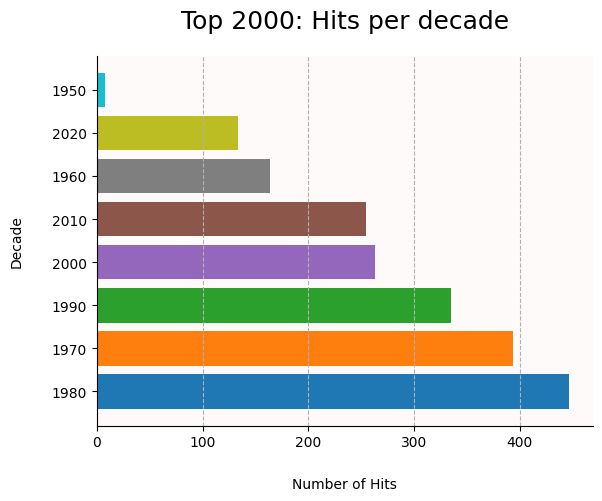

In [128]:
df["Decade"] = np.floor(df["Jaartal"]/10) * 10

decade_df = df["Decade"].value_counts().reset_index()
decade_df["Decade"] = decade_df["Decade"].astype(int)
decade_df

fig, ax = plt.subplots()

cmap = plt.cm.tab10
colors = cmap(np.linspace(0, 1, len(decade_df)))

ax.barh(decade_df["Decade"].astype(str), decade_df["count"], height=0.8, color=colors)
ax.set_title("Top 2000: Hits per decade", fontsize=18, pad=20)
ax.set_ylabel("Decade", labelpad=20)
ax.set_xlabel("Number of Hits", labelpad=20)
ax.grid(axis="x", linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
ax.set_facecolor((1, 0, 0, 0.02))

plt.tight_layout
plt.show()

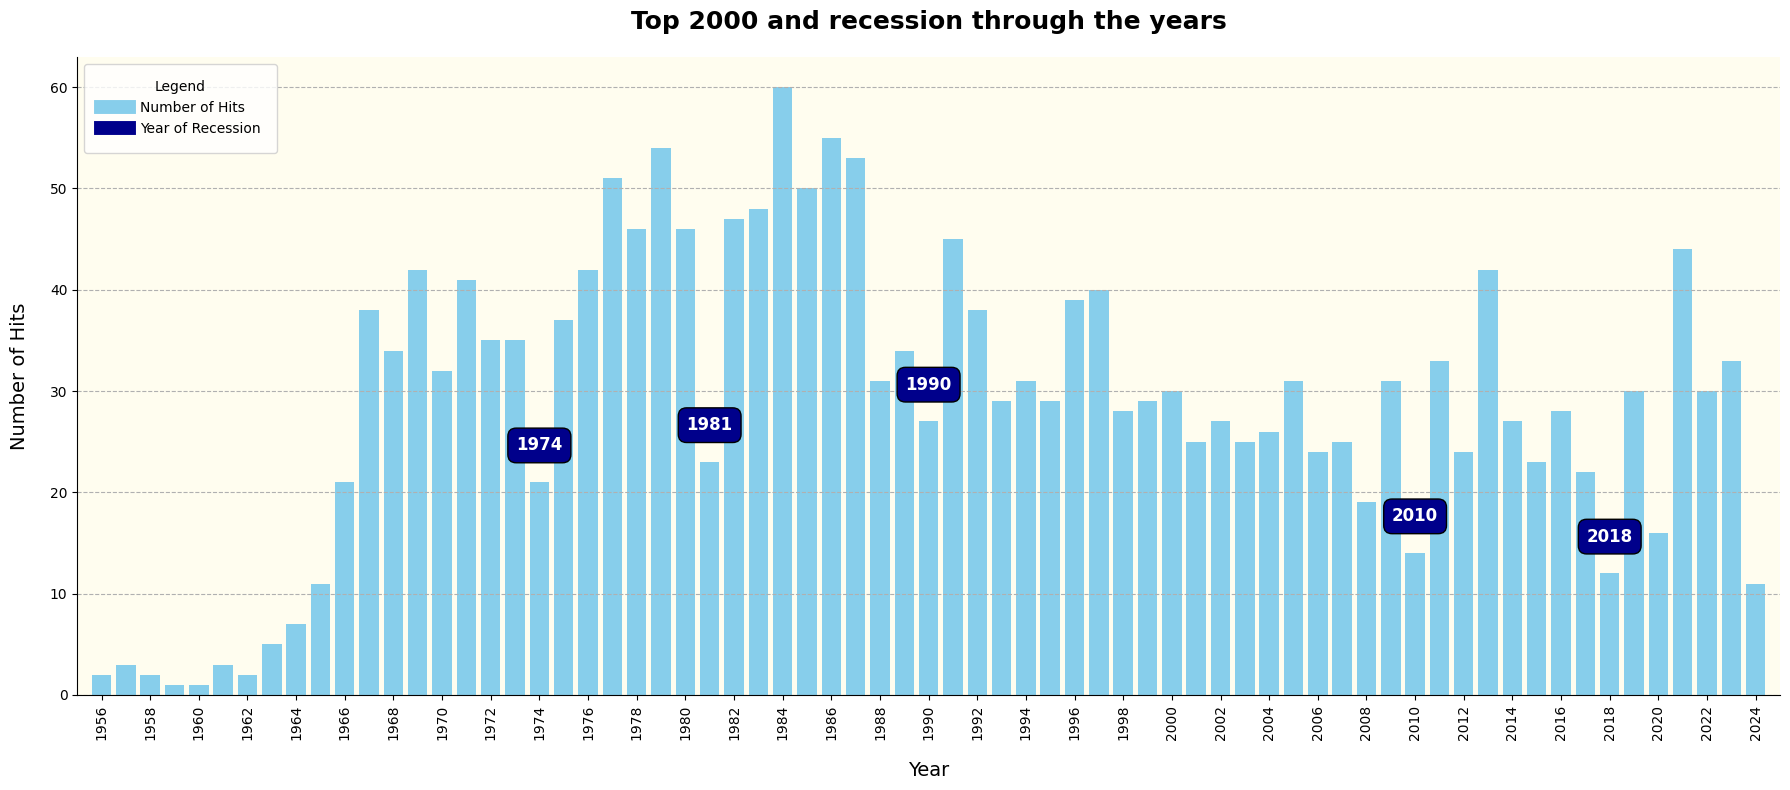

In [260]:
hits_per_jaartal = df["Jaartal"].value_counts().reset_index()
hits_per_jaartal


fig, ax = plt.subplots(figsize=(18, 8))

# Plot all years as bars
bars = ax.bar(hits_per_jaartal["Jaartal"], hits_per_jaartal["count"], color="skyblue")

# Highlight the specific years of interest
special_years = [1974, 1981, 1990, 2010, 2018]
for year in special_years:
    count = hits_per_jaartal.loc[hits_per_jaartal["Jaartal"] == year]["count"].iloc[0]
    ax.annotate(
        str(year),
        xy=(year, count),          # Coordinates for the annotation
        xytext=(0, 20),             # Offset annotation slightly above the bar
        textcoords="offset points",
        ha="center",               # Center-align the annotation
        va="bottom",               # Align it at the bottom of the text box
        fontsize=12,               # Font size for readability
        color="white",             # Annotation text color
        fontweight="bold",          # Make it stand out
        bbox={
            "boxstyle":"round,pad=0.5",  # Rounded corners with padding
            "edgecolor":"black",         # Border color
            "facecolor":"darkblue",      # Background color
        }
    )

# Add title and labels for context
ax.set_title("Top 2000 and recession through the years", fontsize=18, weight="bold", pad=20)
ax.set_xlabel("Year", fontsize=14, labelpad=15)
ax.set_ylabel("Number of Hits", fontsize=14, labelpad=15)
ax.grid(axis="y", linestyle="--")

even_years = hits_per_jaartal.loc[hits_per_jaartal["Jaartal"] % 2 == 0]["Jaartal"]
# Highlight ticks only for special years
ax.set_xticks(even_years)
ax.set_xticklabels(even_years, fontsize=10, rotation=90)
ax.set_xlim(1955, 2025)

# Remove unnecessary spines for cleaner visualization
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_facecolor("#FFFDEF")

handles = [
    plt.Line2D([0], [0], color="skyblue", lw=10, label="Number of Hits"),  # Bars
    plt.Line2D([0], [0], color="darkblue", lw=10, label="Year of Recession"),
]
ax.legend(handles=handles, loc="upper left", title="Legend", fontsize=10, borderpad=1.2)

plt.tight_layout()
plt.show()


In [5]:
url="https://nl.wikipedia.org/wiki/Lijst_van_Radio_2-Top_2000%27s"
top2000 = pd.read_html(url, match="Artiest")

# clean data and rename columns names
data_df = top2000[0]
data_df.columns = ["artiest", "titel", "jaar", "HP"] + [str(year) for year in range(1999, 2025)]

# ad the columns decennium
data_df["decennium"] = np.floor(data_df["jaar"] / 10)*10
data_df["decennium"] = data_df["decennium"].astype(int)

# hits per decennium
data_df.columns = data_df.columns.astype(str)

# replace x and - with np.nan
data_df.replace({"×": np.nan, "—": np.nan}, inplace=True)
#data_df
#data_df.to_csv("data_df.csv")

# new dateframe with songs per decennium
top2000_decade = data_df.groupby("decennium")[data_df.columns[4:30]].count().reset_index()
top2000_decade

,decennium,1999,2000,2001,2002,2003,2004,2005,2006,2007,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,1920,1,1,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1930,3,2,3,3,3,3,4,4,4,...,2,1,0,0,0,0,0,0,0,0
2,1940,4,2,3,2,2,2,2,1,1,...,0,0,0,0,0,0,0,0,0,0
3,1950,61,44,45,44,52,41,37,38,38,...,9,10,10,11,10,8,9,10,9,8
4,1960,537,541,482,500,479,482,473,459,437,...,245,228,219,209,205,191,193,183,170,168
5,1970,754,767,771,753,756,747,742,722,677,...,467,473,468,435,431,435,430,411,404,392
6,1980,501,548,536,527,510,513,480,478,458,...,447,436,442,449,453,463,469,466,454,449
7,1990,139,94,153,162,177,181,199,214,242,...,329,331,336,340,340,337,331,328,325,327
8,2000,0,1,6,9,21,30,62,84,143,...,272,283,275,291,286,281,266,269,269,269
9,2010,0,0,0,0,0,0,0,0,0,...,229,238,250,265,275,277,262,253,255,257


In [116]:
df_final = top2000_decade.iloc[4:8]

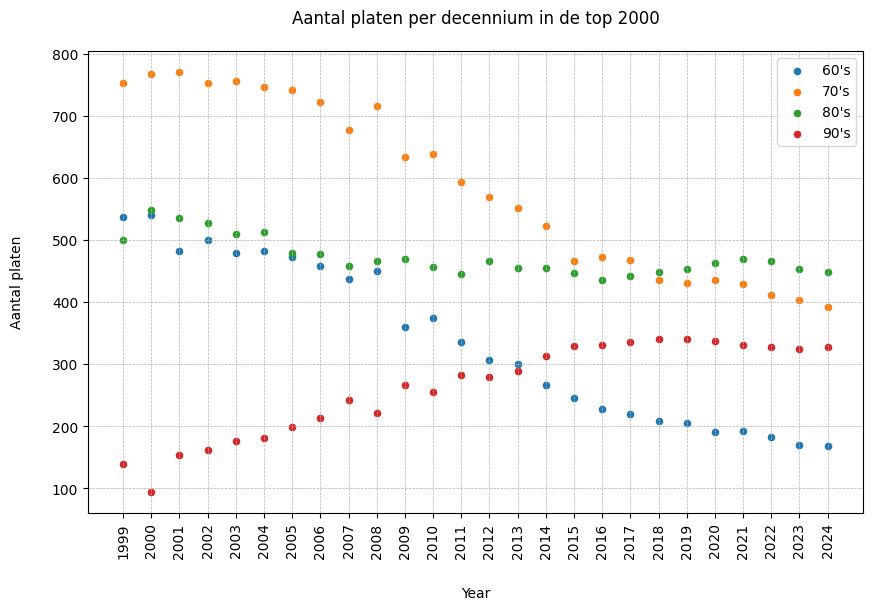

In [121]:
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(df_final.columns[1:], df_final.iloc[0, 1:].values, s=20, label="60's")
ax.scatter(df_final.columns[1:], df_final.iloc[1, 1:].values, s=20, label="70's")
ax.scatter(df_final.columns[1:], df_final.iloc[2, 1:].values, s=20, label="80's")
ax.scatter(df_final.columns[1:], df_final.iloc[3, 1:].values, s=20, label="90's")

ax.set_title("Aantal platen per decennium in de top 2000", pad=20)
ax.set_xticks(df_final.columns[1:])
ax.set_xticklabels(df_final.columns[1:], rotation=90)

ax.set_xlabel("Year", labelpad=20)
ax.set_ylabel("Aantal platen", labelpad=20)

ax.grid(axis="both", linewidth=0.5, linestyle="--")
ax.legend()

plt.show()

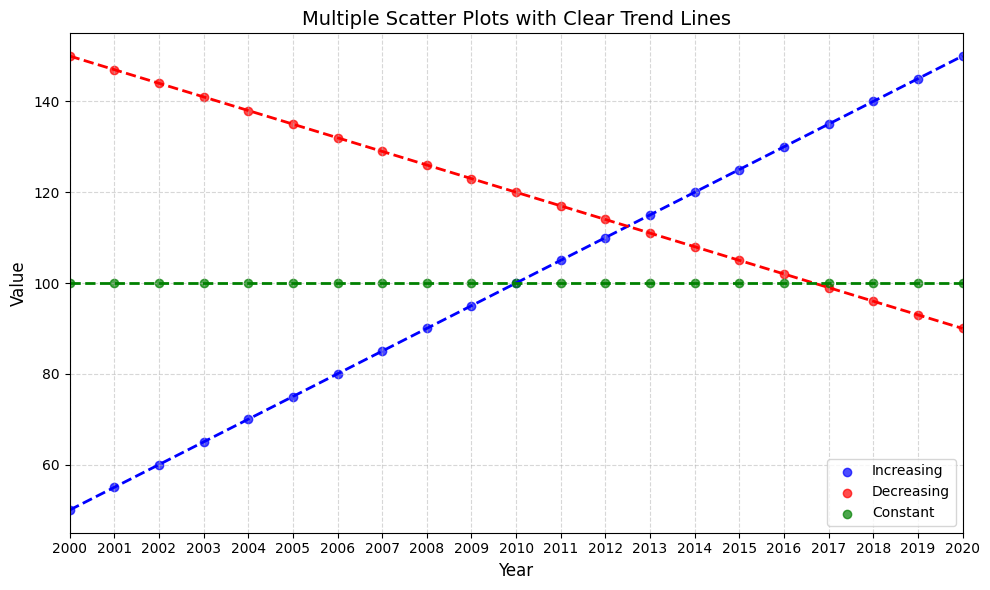

In [245]:
import numpy as np
import matplotlib.pyplot as plt

# Generate example data
x = np.arange(2000, 2021)  # Years (x-axis)

# Create y-values for three different trends
y1 = 5 * (x - 2000) + 50   # Increasing trend, rescaled
y2 = -3 * (x - 2000) + 150  # Decreasing trend, rescaled
y3 = np.full_like(x, 100)   # Constant values

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each scatter plot with its trend line
# Increasing trend (y1)
ax.scatter(x, y1, color='blue', label="Increasing", alpha=0.7)
coeffs1 = np.polyfit(x, y1, 1)  # Linear trend line
trend1 = np.poly1d(coeffs1)
ax.plot(x, trend1(x), color='blue', linestyle="--", linewidth=2)

# Decreasing trend (y2)
ax.scatter(x, y2, color='red', label="Decreasing", alpha=0.7)
coeffs2 = np.polyfit(x, y2, 1)  # Linear trend line
trend2 = np.poly1d(coeffs2)
ax.plot(x, trend2(x), color='red', linestyle="--", linewidth=2)

# Constant trend (y3)
ax.scatter(x, y3, color='green', label="Constant", alpha=0.7)
coeffs3 = np.polyfit(x, y3, 0)  # Constant trend (horizontal line)
trend3 = np.poly1d(coeffs3)
ax.plot(x, trend3(x), color='green', linestyle="--", linewidth=2)

# Customize the plot
ax.set_title("Multiple Scatter Plots with Clear Trend Lines", fontsize=14)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Value", fontsize=12)
ax.set_xticks(x)
ax.set_xlim(x.min(),x.max())
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

# Display the plot
plt.tight_layout()
plt.show()


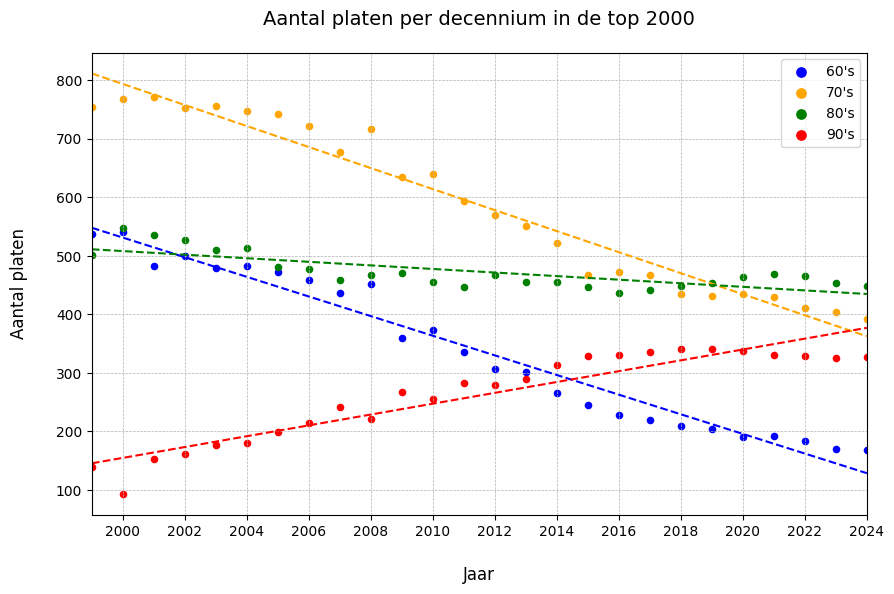

In [201]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Function to add a trend line
def add_trend_line(x, y, ax, color, label=None):
    coefficients = np.polyfit(x, y, deg=1)  # Fit a linear trend line
    trend_line = np.poly1d(coefficients)  # Create a function for the trend line
    ax.plot(x, trend_line(x), color=color, linestyle="--", label=f"{label} trend" if label else None)

# Plot scatter points and add trend lines
decades = ["60's", "70's", "80's", "90's"]
colors = ["blue", "orange", "green", "red"]

# Ensure x-values are numeric years
years = df_final.columns[1:].astype(int)  # Convert x-labels to integers if necessary

for i, decade in enumerate(decades):
    x = years  # Numeric years for x-values
    y = df_final.iloc[i, 1:].values
    ax.scatter(x, y, s=20, label=decade, color=colors[i])
    add_trend_line(x, y, ax, color=colors[i])
 
# Customize the plot
ax.set_title("Aantal platen per decennium in de top 2000", fontsize=14, pad=20)

tick_range = np.arange(years.min()+1, years.max()+1, 2)
ax.set_xticks(tick_range)  # Use years for ticks
ax.set_xticklabels(tick_range, fontsize=10)
ax.set_xlim(1999, 2024)  # Ensure this matches the range of your x-values

ax.set_xlabel("Jaar", fontsize=12, labelpad=20)
ax.set_ylabel("Aantal platen", fontsize=12, labelpad=20)

ax.grid(axis="both", linewidth=0.5, linestyle="--")
ax.legend(loc="upper right", fontsize=10, markerscale=1.5, frameon=True)

plt.show()


In [20]:
langste_titel = list(df["Titel"].values)
longest_title = sorted(langste_titel, key=len, reverse=True)
longest_title[0:10]

['We Are Never Ever Getting Back Together (Taylor’s Version)',
 "It's A Long Way To The Top (If You Wanna Rock 'N Roll)",
 'Love Me Just A Little Bit More (Totally Hooked On You)',
 "It's The End Of The World As We Know It (Albumversie)",
 'San Francisco (Be Sure To Wear Flowers In Your Hair)',
 'Impossible (Orchestral Version Live at Abbey Road)',
 "You Can't Always Get What You Want (Albumversie)",
 'Diamonds On The Soles Of Her Shoes (Albumversie)',
 '(Everything I Do) I Do It For You (Albumversie)',
 'If You Tolerate This Your Children Will Be Next']

In [25]:
import re

# Step 1: Extract titles from the DataFrame
langste_titel = list(df["Titel"].values)

# Step 2: Clean titles to remove parts like "(album versie)"
cleaned_titles = [re.sub(r"\s*\(.*?\)", "", title) for title in langste_titel]

# Step 3: Sort cleaned titles by length and get the top 10 longest titles
top_10_longest_titles = sorted(cleaned_titles, key=len, reverse=True)[:10]

top_10_longest_titles


['If You Tolerate This Your Children Will Be Next',
 'Zing, Vecht, Huil, Bid, Lach, Werk En Bewonder',
 "I Still Haven't Found What I'm Looking For",
 "You're The First, The Last, My Everything",
 'You Took The Words Right Out Of My Mouth',
 "Why'd You Only Call Me When You're High?",
 'We Are Never Ever Getting Back Together',
 'Something Happened On The Way To Heaven',
 "It's The End Of The World As We Know It",
 'Just A Little Bit Of Peace In My Heart']